# Benchmark: PXD014777 HeLa 10 replicate dataset


Let's start with the imports.


In [1]:
%%capture

%matplotlib inline
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import umap
import seaborn as sns
import pickle
import scanpy as sc

import pipp
import pipp.utils

np.random.seed(0)

Let's define the paths to the data and the pretrained model.


In [2]:
PRETRAINED_MODEL_PATH = "../../checkpoints/checkpoint1.pth"

HELA_MS_OUT_PATH = "../../data/PXD014777/processed/hela_ms1.csv"
HELA_MSMS_OUT_PATH = "../../data/PXD014777/processed/hela_ms2.csv"

In [3]:
df_ms_hela = pd.read_csv(HELA_MS_OUT_PATH, low_memory=False)
df_msms_hela = pd.read_csv(HELA_MSMS_OUT_PATH, low_memory=False)

## PIPP model


### Computing the Embeddings


Let's load the model and compute the embeddings.


In [4]:
model = pipp.Peptideprotonet.load(PRETRAINED_MODEL_PATH)

In [5]:
msms_ms1_embeddings = model.compute_ms1_embeddings(df_msms_hela)

In [6]:
msms_ms1_embeddings -= msms_ms1_embeddings.mean(axis=0)

Let's look at the embedding space.
We'll look at a subset of peptides due to memory limitations.


In [7]:
n = 50_000
random_indices = np.random.choice(range(len(msms_ms1_embeddings)), size=n, replace=False)

Let's also add some "random" peptides to ensure all possible runs of at least a few peptides are included.


In [8]:
high_coverage_peptides_to_include = [
    "_(ac)AAAAAAAAAAGAAGGR_2",
    "_LGMENDDTAVQYAIGR_2",
    "_LGHVVMGNNAVSPYQQVIEK_2",
    "_LEEVLSTEGAEENGNSDK_2",
    "_PAPQMNGSTGDAR_2",
    "_HLQINQTFEELR_2",
    "_LLAGEDGTSER_2",
    "_LETMPLYLEDDIRPDIK_3",
    "_LFNDSSPVVLEESWDALNAITK_3",
]

low_coverage_peptides_to_include = [
    "_ELFEQYGAVYEINVLR_3",
    "_ELFDELVK_2",
    "_FLGDYVENLNK_2",
    "_HHSQQAPQAEAPCLLR_3",
    "_HFSTTTNNIQSR_2",
    "_LEEIAELVASSLPSPLR_3",
    "_AVLEQFGFPLTGTEAR_2",
    "_VPQFSFLDIFPK_2",
    "_VGPYHNPQETYHYYQLPVCCPEK_3",
    "_FDSASSSYYLDMHSLPHVINPVESR_4",
]

peptides_to_include = (
    high_coverage_peptides_to_include + low_coverage_peptides_to_include
)

custom_indices = [
    df_msms_hela.index[df_msms_hela["PrecursorID"] == peptide].tolist()
    for peptide in peptides_to_include
]
custom_indices = [
    peptide for peptide_runs in custom_indices for peptide in peptide_runs
]
custom_indices = [df_msms_hela.index.get_loc(i) for i in custom_indices]

In [9]:
indices = np.unique(np.concatenate((random_indices, custom_indices)))

In [10]:
df_msms_hela_subset = df_msms_hela.iloc[indices]
msms_embeddings_subset = msms_ms1_embeddings[indices]

Let's compute the UMAP for plotting.


In [11]:
reducer = umap.UMAP(metric="cosine")
umap_embedding = reducer.fit_transform(msms_embeddings_subset)

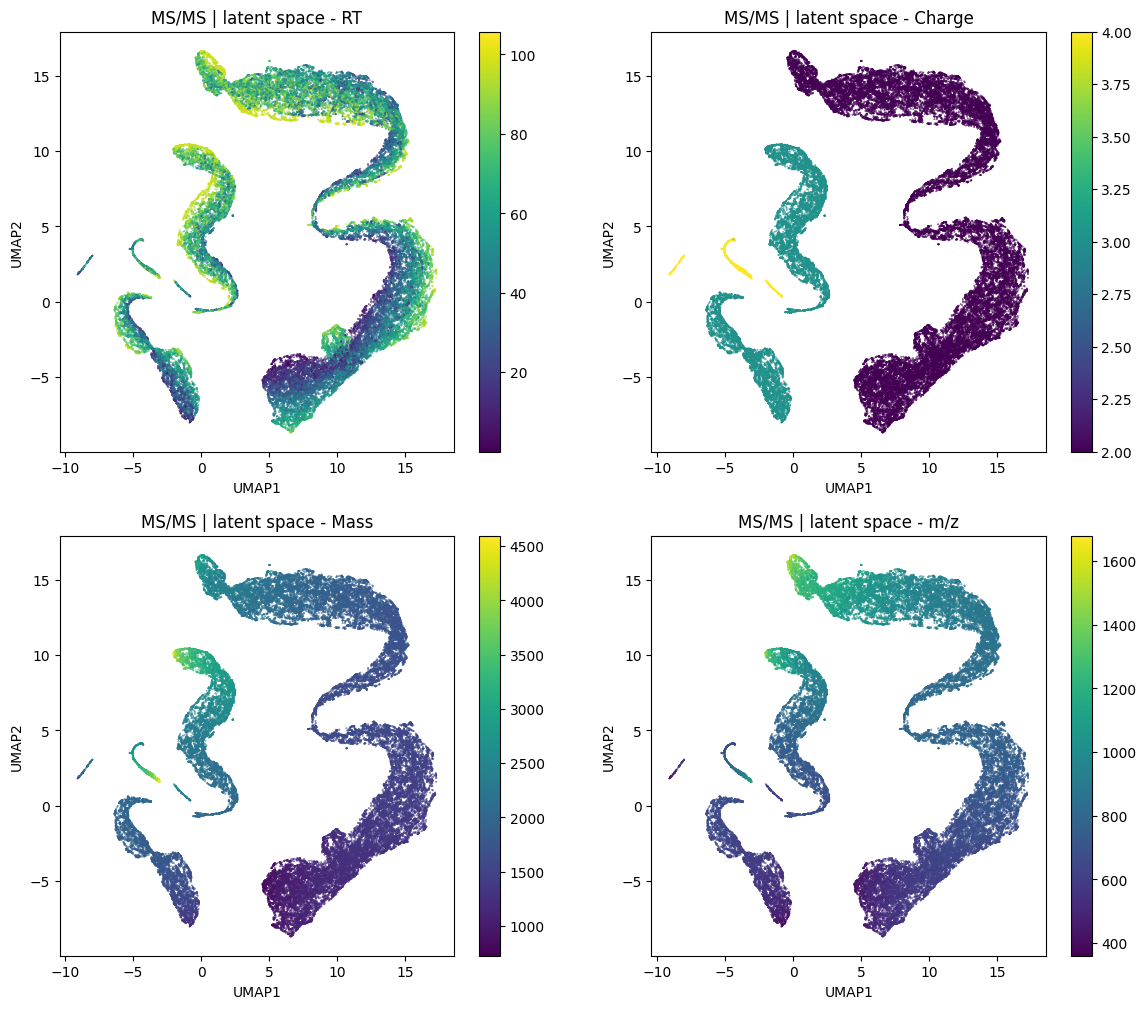

In [12]:
fig, axs = plt.subplots(figsize=(14, 12), ncols=2, nrows=2)

ax = axs[0][0]
sp = ax.scatter(
    umap_embedding[:, 0],
    umap_embedding[:, 1],
    c=df_msms_hela_subset["Retention time"],
    s=0.1,
)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("MS/MS | latent space - RT")
fig.colorbar(sp)

ax = axs[0][1]
sp = ax.scatter(
    umap_embedding[:, 0], umap_embedding[:, 1], c=df_msms_hela_subset["Charge"], s=0.1
)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("MS/MS | latent space - Charge")
fig.colorbar(sp)

ax = axs[1][0]
sp = ax.scatter(
    umap_embedding[:, 0], umap_embedding[:, 1], c=df_msms_hela_subset["Mass"], s=0.1
)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("MS/MS | latent space - Mass")
fig.colorbar(sp)

ax = axs[1][1]
sp = ax.scatter(
    umap_embedding[:, 0], umap_embedding[:, 1], c=df_msms_hela_subset["m/z"], s=0.1
)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("MS/MS | latent space - m/z")
fig.colorbar(sp)

Let's also plot the latent space of the MS/MS data together with some low coverage and high coverage peptides.


In [13]:
peptide_abundances = df_msms_hela["PrecursorID"].value_counts()

Text(0.5, 1.0, 'MS/MS | latent space - low coverage peptides')

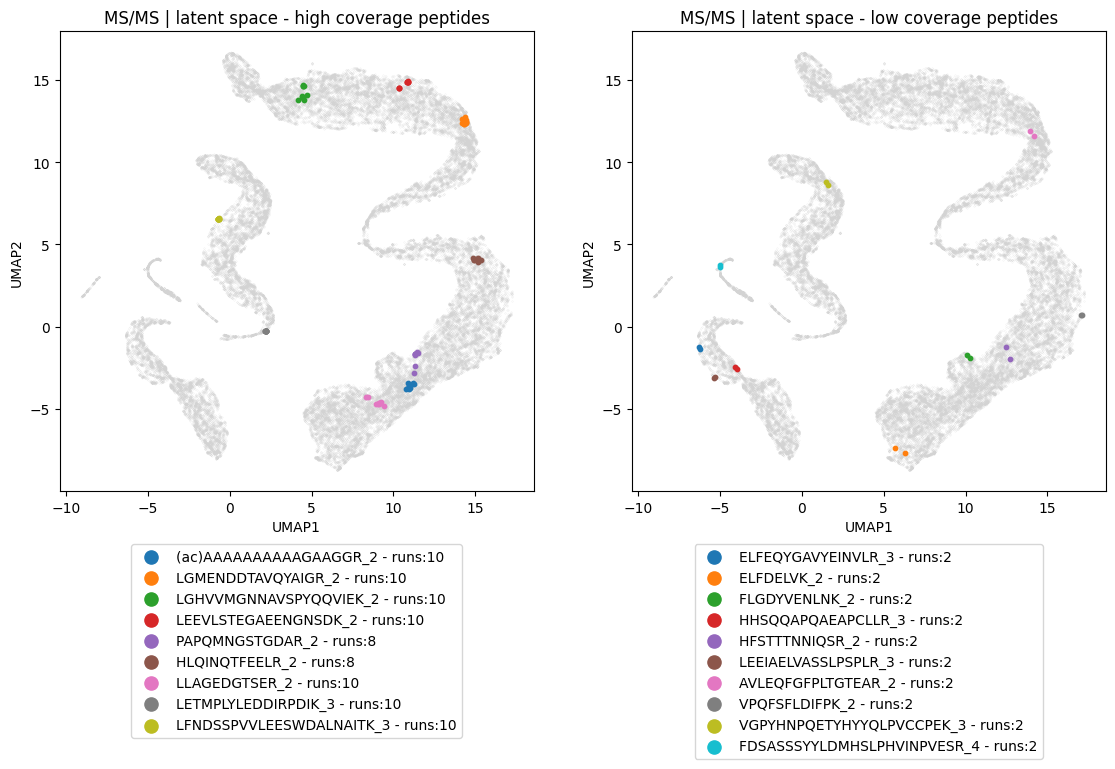

In [14]:
fig, axs = plt.subplots(figsize=(12, 6), ncols=2, nrows=1)
fig.tight_layout(pad=4.0)

# high coverage peptides
ax = axs[0]
ax.scatter(umap_embedding[:, 0], umap_embedding[:, 1], s=0.01, color="lightgrey")

for i, peptide in enumerate(high_coverage_peptides_to_include):
    peptide_ref_indices = np.where(df_msms_hela_subset["PrecursorID"] == peptide)
    ax.scatter(
        umap_embedding[peptide_ref_indices, 0],
        umap_embedding[peptide_ref_indices, 1],
        s=10,
        color=plt.cm.tab10(i),
        label=f"{peptide[1:]} - runs:{peptide_abundances[peptide]}",
    )

ax.legend(markerscale=3, loc="upper center", bbox_to_anchor=(0.5, -0.1))
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("MS/MS | latent space - high coverage peptides")

# low coverage peptides
ax = axs[1]
ax.scatter(umap_embedding[:, 0], umap_embedding[:, 1], s=0.01, color="lightgrey")

for i, peptide in enumerate(low_coverage_peptides_to_include):
    peptide_ref_indices = np.where(df_msms_hela_subset["PrecursorID"] == peptide)
    ax.scatter(
        umap_embedding[peptide_ref_indices, 0],
        umap_embedding[peptide_ref_indices, 1],
        s=10,
        color=plt.cm.tab10(i),
        label=f"{peptide[1:]} - runs:{peptide_abundances[peptide]}",
    )

ax.legend(markerscale=3, loc="upper center", bbox_to_anchor=(0.5, -0.1))
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("MS/MS | latent space - low coverage peptides")

## Peptide Identity Propagation


### Optional: Preparing MSMS sequence embeddings


See `hela_multi_analysis.ipynb` for more info on how to generate MSMS sequence embeddings.

Assuming the embeddings are already generated, let's load them. Change the path to the embeddings file if needed. Afterwards, define the number of PCA components to use for the embeddings.


In [15]:
PATH = "../../data/PXD014777/embeddings/prototype_embeddings.pkl"
N_PCS = 5

try:
    with open(PATH, "rb") as f:
        prototype_embeddings = pickle.load(f)

    ms2_embeddings = pipp.utils.pca(prototype_embeddings, n_pcs=N_PCS)
except FileNotFoundError:
    print("MSMS sequence embedding file not found!")
    ms2_embeddings = None

MSMS sequence embedding file not found!


### Identification on the MS data

In [16]:
df_ms_hela.set_index("id", inplace=True, drop=False)
df_msms_hela.set_index("id", inplace=True, drop=False)

ms_only_locs = df_ms_hela.index.difference(df_msms_hela.index)
df_ms_hela_query = df_ms_hela.loc[ms_only_locs]

In [17]:
k_neighbours = 5
n_anchor = 30

identifications, confidence = model.propagate(
    df_ms_hela_query,
    df_msms_hela,
    k_neighbours=k_neighbours,
    n_anchors=n_anchor,
    ms2_embeddings=ms2_embeddings,
)

Let's plot the distribution of the confidence scores for the MS identifications. Additionally, we'll add a threshold to the plot, which we'll use to filter out low confidence identifications.


Text(0.31, 500000.0, 'Peptides identified: 1052316 (42.78%)')

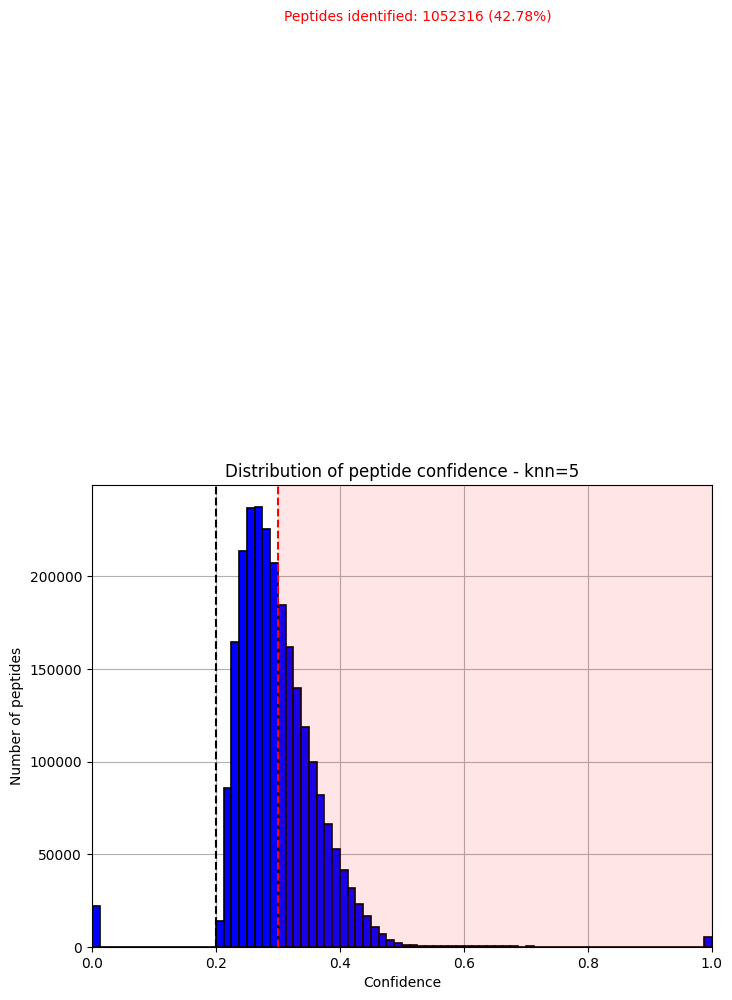

In [19]:
confidence_threshold = 0.3

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(confidence, bins=80, color="blue", edgecolor="black", linewidth=1.2)
ax.set_xlabel("Confidence")
ax.set_ylabel("Number of peptides")
ax.set_title(f"Distribution of peptide confidence - knn={k_neighbours}")
ax.set_xlim([0, 1])
ax.grid(True)
ax.set_axisbelow(True)

ax.axvline(x=confidence_threshold, color="red", linestyle="--")
ax.axvline(x=1 / k_neighbours, color="black", linestyle="--")
ax.axvspan(confidence_threshold, 1, alpha=0.1, color="red")

identified_count = np.sum(confidence > confidence_threshold)
ax.text(
    confidence_threshold + 0.01,
    5e5,
    f"Peptides identified: {identified_count} ({identified_count / len(df_ms_hela_query) * 100:.2f}%)",
    color="red",
)

Let's plot the number of peptides identified for different thresholds.


Text(0, 0.5, 'Percentage of peptides identified (%)')

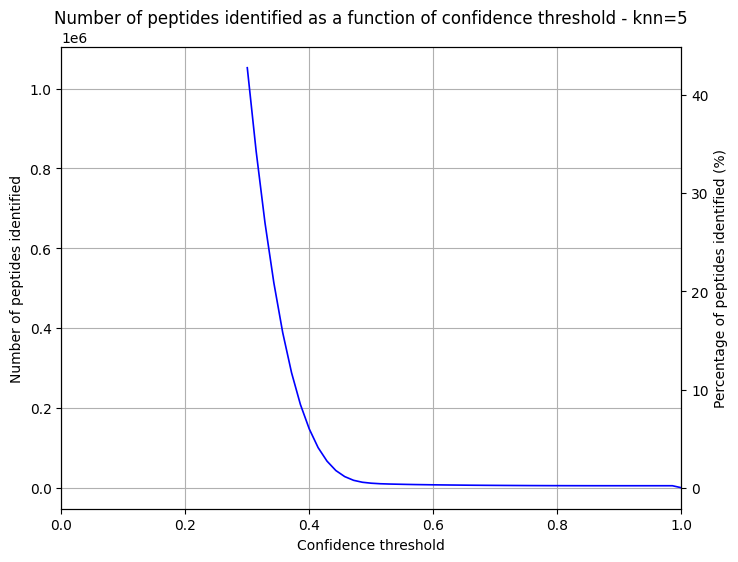

In [20]:
thresholds = np.linspace(0.3, 1, 50)
identified_counts = [np.sum(confidence > threshold) for threshold in thresholds]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(thresholds, identified_counts, color="blue", linewidth=1.2)

ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Number of peptides identified")
ax.set_title(
    f"Number of peptides identified as a function of confidence threshold - knn={k_neighbours}"
)
ax.set_xlim([0, 1])
ax.grid(True)
ax.set_axisbelow(True)

ax2 = ax.twinx()
ax2.plot(
    thresholds,
    np.array(identified_counts) / len(df_ms_hela_query) * 100,
    color="red",
    linewidth=0,
)  # @NOTE: linewidth=0 to hide the line
ax2.set_ylabel("Percentage of peptides identified (%)")

Let's generate a dataframe with the results combining both the MS (excluding the MS/MS data entries) and MS/MS data using the features: run (raw file), Intensity, precursorID, confidence. We'll use these features to generate the expression matrices (and heatmaps).


In [21]:
ms_results = {
    "Raw file": df_ms_hela_query["Raw file"],
    "Intensities": df_ms_hela_query["Intensity"],
    "PrecursorID": identifications,
    "confidence": confidence,
}

msms_results = {
    "Raw file": df_msms_hela["Raw file"],
    "Intensities": df_msms_hela["Intensity"],
    "PrecursorID": df_msms_hela["PrecursorID"],
}


ms_results = pd.DataFrame(ms_results)
msms_results = pd.DataFrame(msms_results)

Due to the propagation, there may be entries with the same 'Raw file' and 'PrecursorID'. For these overlapping entries, only the entry with the largest intensity is kept when plotting the heatmap for the MS expression matrix.


In [24]:
df_x = pipp.utils.filter_by_highest_intensity(ms_results)
ms_adata = pipp.utils.create_abundance_matrix(df_x, layer_keys=["confidence"])

sc.pp.log1p(ms_adata, layer="raw")

In [25]:
df_x = pipp.utils.filter_by_highest_intensity(msms_results)
msms_adata = pipp.utils.create_abundance_matrix(df_x)

sc.pp.log1p(msms_adata, layer="raw")

In [26]:
adata = sc.AnnData(obs=msms_adata.obs, var=msms_adata.var)
adata.layers["msms"] = msms_adata.layers["raw"].copy()

ms_adata.X = ms_adata.layers["raw"].copy()
adata_like = pipp.utils.reshape_anndata_like(ms_adata, adata)
adata.layers["ms"] = adata_like.X.copy()

ms_adata.X = ms_adata.layers["confidence"].copy()
adata_like = pipp.utils.reshape_anndata_like(ms_adata, adata)
adata.layers["ms_confidence"] = adata_like.X.copy()

In [27]:
confidence_threshold = 0.5
mask = adata.layers["ms_confidence"] > confidence_threshold

adata.layers["ms_threshold"] = adata.layers["ms"].copy()
adata.layers["ms_threshold"][~mask] = np.nan

In [28]:
nan_mask = np.isnan(adata.layers["msms"])

adata.layers["combined"] = adata.layers["msms"].copy()
adata.layers["combined"][nan_mask] = adata.layers["ms_threshold"][nan_mask]

In [29]:
mask = np.any(~np.isnan(adata.layers["ms_threshold"]), axis=0)

adata_subset = adata[:, mask]

Let's plot the heatmaps.


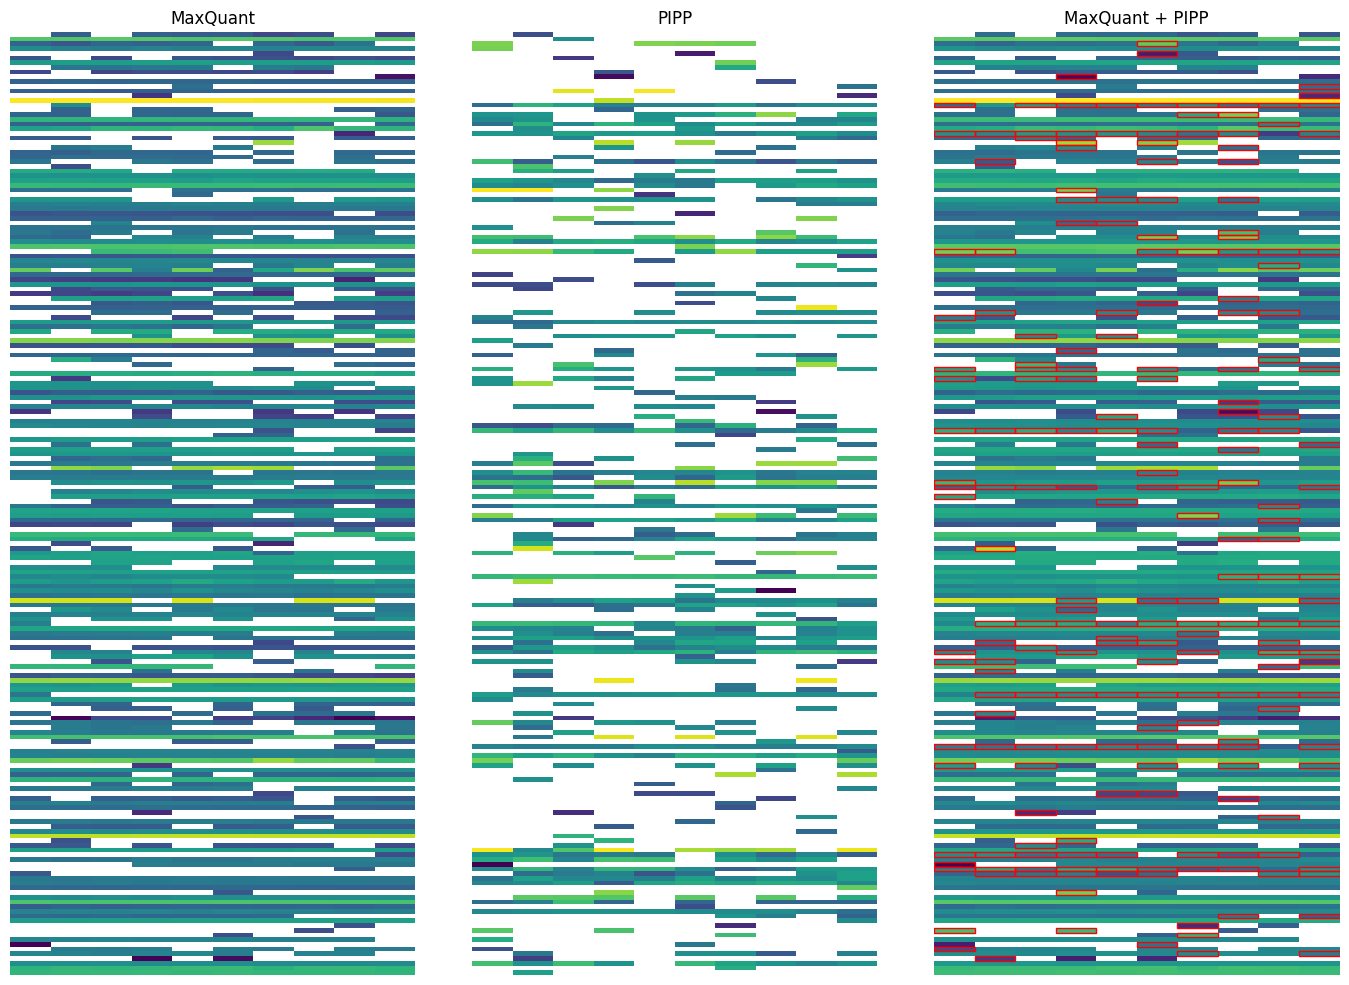

In [30]:
N = 200

adata_subset_t = adata_subset.copy().T
adata_subset_t = adata_subset_t[:N]

fig, axs = plt.subplots(figsize=(14, 10), ncols=3, nrows=1)
fig.tight_layout(pad=1.0)

# MaxQuant
ax = axs[0]
ax.set_title("MaxQuant")
ax.set_xlabel("Run")
ax.set_ylabel("Peptide")
sns.heatmap(
    adata_subset_t.layers["msms"],
    ax=ax,
    cmap="viridis",
    xticklabels=False,
    yticklabels=False,
    cbar=False,
)

# PIPP
ax = axs[1]
ax.set_title("PIPP")
ax.set_xlabel("Run")
ax.set_ylabel("Peptide")
sns.heatmap(
    adata_subset_t.layers["ms_threshold"],
    ax=ax,
    cmap="viridis",
    xticklabels=False,
    yticklabels=False,
    cbar=False,
)

# PIPP + MaxQuant
ax = axs[2]
ax.set_title("MaxQuant + PIPP")
ax.set_xlabel("Run")
ax.set_ylabel("Peptide")
ax = sns.heatmap(
    adata_subset_t.layers["combined"],
    ax=ax,
    cmap="viridis",
    xticklabels=False,
    yticklabels=False,
    cbar=False,
)

ms_threshold_only_mask = np.isnan(adata_subset_t.layers["msms"]) & ~np.isnan(
    adata_subset_t.layers["ms_threshold"]
)
for row in range(ms_threshold_only_mask.shape[0]):
    for col in range(ms_threshold_only_mask.shape[1]):
        if not ms_threshold_only_mask[row, col]:
            continue

        ax.add_patch(
            plt.Rectangle(
                (col, row),
                1,
                1,
                fill=False,
                edgecolor="red",
                lw=1,
            )
        )

In [31]:
adata_subset_t = adata_subset.copy().T

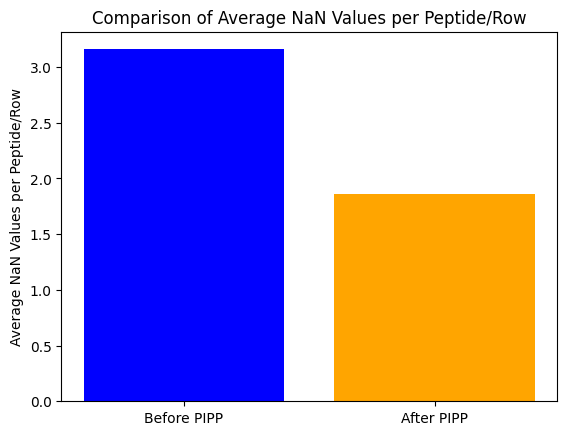

In [32]:
fig, ax = plt.subplots()

nan_count_before = np.isnan(adata_subset_t.layers["msms"]).sum(axis=1)
nan_count_after = np.isnan(adata_subset_t.layers["combined"]).sum(axis=1)

avg_nan_before = nan_count_before.mean()
avg_nan_after = nan_count_after.mean()

ax.bar(
    ["Before PIPP", "After PIPP"],
    [avg_nan_before, avg_nan_after],
    color=["blue", "orange"],
)
ax.set_ylabel("Average NaN Values per Peptide/Row")
ax.set_title("Comparison of Average NaN Values per Peptide/Row")
plt.show()

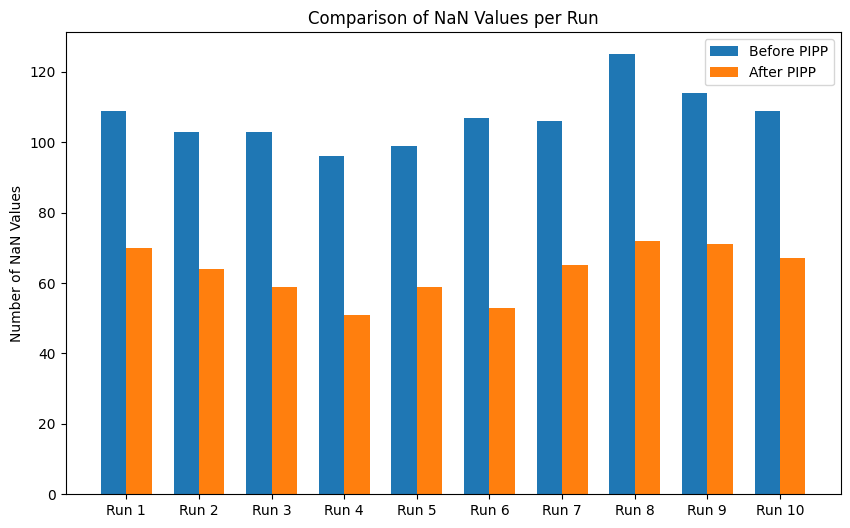

In [33]:
nan_count_before_c = np.isnan(adata_subset_t.layers["msms"]).sum(axis=0)
nan_count_after_c = np.isnan(adata_subset_t.layers["combined"]).sum(axis=0)

fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35

bar_positions_before_c = np.arange(len(nan_count_before_c))
bar_positions_after_c = bar_positions_before_c + bar_width

ax.bar(bar_positions_before_c, nan_count_before_c, width=bar_width, label="Before PIPP")
ax.bar(bar_positions_after_c, nan_count_after_c, width=bar_width, label="After PIPP")

ax.set_xticks(bar_positions_before_c + bar_width / 2)
ax.set_xticklabels([f"Run {i + 1}" for i in range(len(nan_count_before_c))])
ax.set_ylabel("Number of NaN Values")
ax.set_title("Comparison of NaN Values per Run")
ax.legend()

plt.show()

In [34]:
def compute_cv(vs: np.ndarray) -> np.ndarray:
    return np.nanstd(vs, axis=1) / np.nanmean(vs, axis=1)

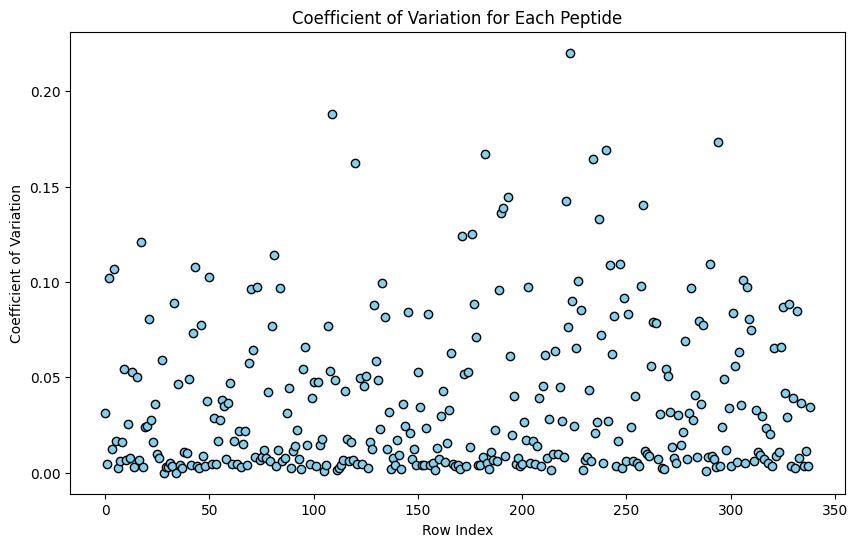

In [35]:
cv = compute_cv(adata_subset_t.layers["combined"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x=np.arange(len(cv)), y=cv, color="skyblue", edgecolor="black")

ax.set_xlabel("Row Index")
ax.set_ylabel("Coefficient of Variation")
ax.set_title("Coefficient of Variation for Each Peptide")

plt.show()

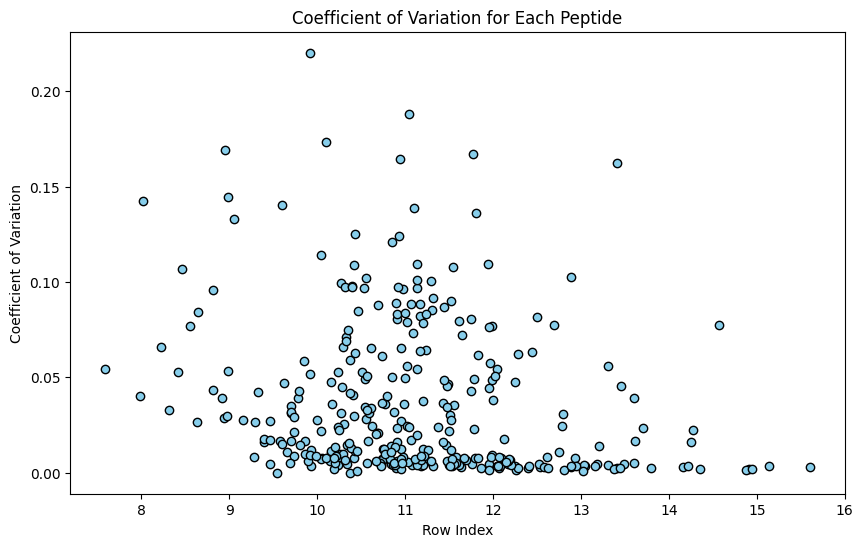

In [36]:
mean = np.nanmean(adata_subset_t.layers["combined"], axis=1)
cv = compute_cv(adata_subset_t.layers["combined"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x=mean, y=cv, color="skyblue", edgecolor="black")

ax.set_xlabel("Row Index")
ax.set_ylabel("Coefficient of Variation")
ax.set_title("Coefficient of Variation for Each Peptide")

plt.show()

### Identification on held-out MS/MS run


Let's hold out all the peptides in the MS/MS dataset for a specific run and see how many of them are identified.


In [37]:
runs = df_ms_hela["Raw file"].unique()

run_to_benchmark = runs[0]
print("Run to benchmark: {}".format(run_to_benchmark))

other_runs = runs[runs != run_to_benchmark]

df_msms_hela_subset = df_msms_hela[df_msms_hela["Raw file"] != run_to_benchmark]
msms_embeddings_subset = msms_ms1_embeddings[df_msms_hela["Raw file"] != run_to_benchmark]

df_msms_hela_benchmark = df_msms_hela[
    df_msms_hela["Raw file"] == run_to_benchmark
].copy()
msms_embeddings_benchmark = msms_ms1_embeddings[df_msms_hela["Raw file"] == run_to_benchmark]

Run to benchmark: 20190122_HeLa_QC_Slot1-47_1_3219


In [38]:
k = 15

identities, confidence = model.propagate(
    df_msms_hela_benchmark, df_msms_hela_subset, k_neighbours=k
)

In [39]:
print(f"Number of prototypes: {df_msms_hela_subset['PrecursorID'].nunique()}")

Number of prototypes: 60544


In [40]:
df_msms_hela_benchmark["Identification"] = identities
df_msms_hela_benchmark["Identification Confidence"] = confidence

Let's plot the distribution of the confidence scores for the MS2 identifications. Additionally, we'll add a threshold to the plot, which we'll use to filter out low confidence identifications.


Text(0.21000000000000002, 5000, 'Peptides identified correctly: 28 (51.85%)')

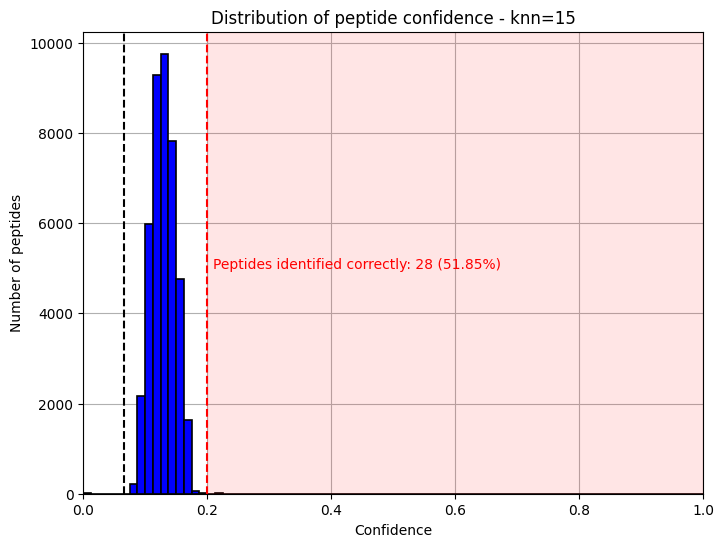

In [41]:
peptide_threshold = 0.2


fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(
    df_msms_hela_benchmark["Identification Confidence"],
    bins=80,
    color="blue",
    edgecolor="black",
    linewidth=1.2,
)
ax.set_xlabel("Confidence")
ax.set_ylabel("Number of peptides")
ax.set_title(f"Distribution of peptide confidence - knn={k}")
ax.set_xlim([0, 1])
ax.grid(True)
ax.set_axisbelow(True)

ax.axvline(x=peptide_threshold, color="red", linestyle="--")
ax.axvline(x=1 / k, color="black", linestyle="--")
ax.axvspan(peptide_threshold, 1, alpha=0.1, color="red")

benchmark_threshold = df_msms_hela_benchmark[
    df_msms_hela_benchmark["Identification Confidence"] > peptide_threshold
]
matches = np.sum(
    benchmark_threshold["PrecursorID"] == benchmark_threshold["Identification"]
)

identified_count = np.sum(
    df_msms_hela_benchmark["Identification Confidence"] > peptide_threshold
)
ax.text(
    peptide_threshold + 0.01,
    5000,
    f"Peptides identified correctly: {matches} ({matches / benchmark_threshold.shape[0] * 100:.2f}%)",
    color="red",
)

Let's plot the number of peptides identified correctly for different thresholds.


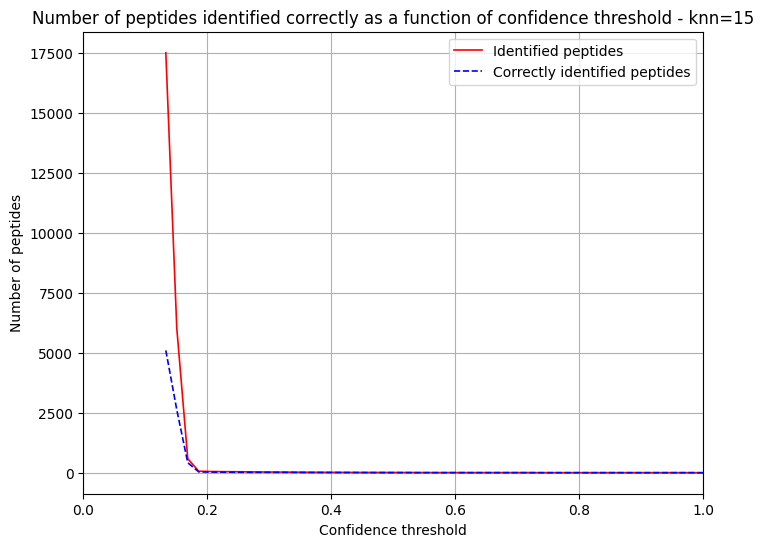

In [42]:
thresholds = np.linspace(1 / k * 2, 1, 50)
identified_counts = []
correct_counts = []

for threshold in thresholds:
    benchmark_threshold = df_msms_hela_benchmark[
        df_msms_hela_benchmark["Identification Confidence"] > threshold
    ]
    matches = np.sum(
        benchmark_threshold["PrecursorID"] == benchmark_threshold["Identification"]
    )
    identified_counts.append(benchmark_threshold.shape[0])
    correct_counts.append(matches)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(
    thresholds,
    identified_counts,
    color="red",
    linewidth=1.2,
    label="Identified peptides",
)
ax.plot(
    thresholds,
    correct_counts,
    color="blue",
    linewidth=1.2,
    linestyle="--",
    label="Correctly identified peptides",
)
ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Number of peptides")
ax.set_title(
    f"Number of peptides identified correctly as a function of confidence threshold - knn={k}"
)
ax.set_xlim([0, 1])
ax.grid(True)
ax.set_axisbelow(True)
ax.legend()